<p align="center">
  <img width=300 src="https://github.com/KempnerInstitute/overcomplete/blob/main/docs/assets/banner.png?raw=True"/>
</p>



# 👋 Welcome to the Overcomplete Starter Tutorial

In this guide, we'll explore how to use Overcomplete to train a simple Sparse Autoencoder (SAE) on top of DINOv2 and visualize the resulting concepts. We'll be working with a small dataset comprising a few hundred images of rabbits. 🐇

Let's get started!

_Author: [Thomas FEL](https://thomasfel.me/)_

In [152]:
!pip install --no-deps -q overcomplete

4850.94s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [167]:
# importing the minimal set of lib
# and download the small rabbit dataset

import torch
import numpy as np
import matplotlib.pyplot as plt

from einops import rearrange
from torchvision import transforms

import overcomplete

!wget -O rabbit.npz -q "https://github.com/KempnerInstitute/Overcomplete/blob/main/docs/assets/rabbit.npz?raw=True"

In [ ]:
from torchvision.datasets.imagenet import 

imagenet_

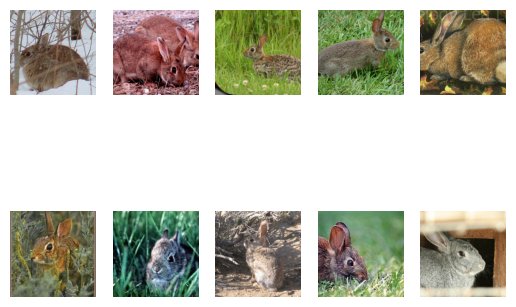

In [ ]:
from overcomplete.visualization import show
# show is able to plot any numpy/pil/tensor and handle various
# data format (channel first, last, no channel...)

images = np.load('rabbit.npz')['arr_0'].astype(np.uint8)
for i in range(10):
  plt.subplot(2, 5, i+1)
  show(images[i])
plt.show()

In [155]:
# lets load a model, and get the activations for this model !
# here we are going to use DinoV2, just because i love this model :)
from overcomplete.models import DinoV2

model = DinoV2(device='cuda')
to_pil = transforms.ToPILImage()

images = [
    model.preprocess(to_pil(image))
    for image in images
]

images = torch.stack(images).cuda()
images.shape

Using cache found in /home/st0pien/.cache/torch/hub/facebookresearch_dinov2_main


torch.Size([300, 3, 224, 224])

In [156]:
# ok then forward and flatten to get the tokens
Activations = model.forward_features(images)

Activations = rearrange(Activations, 'n t d -> (n t) d')
Activations.shape

torch.Size([76800, 384])

In [157]:
from torch import ones, multinomial
from torch.distributions import MultivariateNormal


class WeightedICALossFunction:
    """
    The weighted correlation loss (the independence loss).
    """
    def __init__(self, power, number_of_gausses, cuda, z_dim=None):
        super(WeightedICALossFunction, self).__init__()
        self.power = power
        self.number_of_gausses = number_of_gausses
        self.z_dim = z_dim
        self.cuda = cuda
        self.reduction_type = "mean"

    def random_choice_full(self, input, n_samples):
        if n_samples * self.number_of_gausses < input.shape[0]:
            replacement = False
        else:
            replacement = True
        idx = multinomial(ones(input.shape[0]), n_samples * self.number_of_gausses, replacement=replacement)
        sampled = input[idx].reshape(self.number_of_gausses, n_samples, -1)
        return torch.mean(sampled, axis=1)

    def loss(self, z, latent_normalization=True):
        if latent_normalization:
            x = (z - z.mean(axis=0)) / z.std(axis=0)
        else:
            x = z
        dim = self.z_dim if self.z_dim is not None else x.shape[1]
        scale = (1 / dim) ** self.power
        sampled_points = self.random_choice_full(x, dim)

        cov_mat = (scale * torch.eye(dim)).repeat(self.number_of_gausses, 1, 1)
        if self.cuda:
            cov_mat = cov_mat.cuda()

        mvn = MultivariateNormal(loc=sampled_points,
                                 covariance_matrix=cov_mat)

        weight_vector = torch.exp(mvn.log_prob(x.reshape(-1, 1, dim)))
        sum_of_weights = torch.sum(weight_vector, axis=0)

        weight_sum = torch.sum(x * weight_vector.T.reshape(self.number_of_gausses, -1, 1), axis=1)
        weight_mean = weight_sum / sum_of_weights.reshape(-1, 1)

        xm = x - weight_mean.reshape(self.number_of_gausses, 1, -1)
        wxm = xm * weight_vector.T.reshape(self.number_of_gausses, -1, 1)

        wcov = (wxm.permute(0, 2, 1).matmul(xm)) / sum_of_weights.reshape(-1, 1, 1)

        diag = torch.diagonal(wcov ** 2, dim1=1, dim2=2)
        diag_pow_plus = diag.reshape(diag.shape[0], diag.shape[1], -1) + diag.reshape(diag.shape[0], -1, diag.shape[1])

        tmp = (2 * wcov ** 2 / diag_pow_plus)
        triu = torch.triu(tmp, diagonal=1)
        normalize = 2.0 / (dim * (dim - 1))
        cost = torch.sum(normalize * triu) / self.number_of_gausses
        return cost

In [164]:
# now the funny part, lets train a small topk sae
# we need a dataloader, a criterion and an optimizer
from torch.utils.data import DataLoader, TensorDataset
from overcomplete.sae import TopKSAE, train_sae
from overcomplete.sae.losses import top_k_auxiliary_loss

sae = TopKSAE(Activations.shape[-1], nb_concepts=10, top_k=2, device="cuda")

dataloader = torch.utils.data.DataLoader(
    TensorDataset(Activations), batch_size=1024, shuffle=True
)
optimizer = torch.optim.Adam(sae.parameters(), lr=5e-4)


def criterion(x, x_hat, pre_codes, codes, dictionary):
    mse = (x - x_hat).square().mean()
    return mse


wica_loss = WeightedICALossFunction(1, 2, True)

wica_values = []

def combined_loss(x, x_hat, pre_codes, codes, dictionary, k=2, wica_penalty=100):
    topk = torch.topk(codes, k=k).values
    # print(topk)
    with torch.no_grad():
        wica = wica_loss.loss(topk)
    mse_topk = top_k_auxiliary_loss(x, x_hat, pre_codes, codes, dictionary)
    wica_values.append(wica)
    # print(wica)

    return criterion(x, x_hat, pre_codes, codes, dictionary)
    return mse_topk + wica_penalty * wica


logs = train_sae(
    sae, dataloader, combined_loss, optimizer, nb_epochs=50, device="cuda"
)



Epoch[1/50], Loss: 5.7468, R2: 0.0691, L0: 1.9824, Dead Features: 0.0%, Time: 0.7712 seconds
Epoch[2/50], Loss: 4.4354, R2: 0.2815, L0: 2.0000, Dead Features: 10.0%, Time: 0.8475 seconds
Epoch[3/50], Loss: 3.8850, R2: 0.3707, L0: 2.0000, Dead Features: 10.0%, Time: 0.7242 seconds
Epoch[4/50], Loss: 3.7466, R2: 0.3931, L0: 2.0000, Dead Features: 0.0%, Time: 0.7133 seconds
Epoch[5/50], Loss: 3.6792, R2: 0.4040, L0: 2.0000, Dead Features: 10.0%, Time: 0.7270 seconds
Epoch[6/50], Loss: 3.6360, R2: 0.4110, L0: 2.0000, Dead Features: 10.0%, Time: 0.7520 seconds
Epoch[7/50], Loss: 3.6121, R2: 0.4149, L0: 2.0000, Dead Features: 0.0%, Time: 0.7352 seconds
Epoch[8/50], Loss: 3.5978, R2: 0.4172, L0: 2.0000, Dead Features: 0.0%, Time: 0.7131 seconds
Epoch[9/50], Loss: 3.5873, R2: 0.4189, L0: 2.0000, Dead Features: 0.0%, Time: 0.7220 seconds
Epoch[10/50], Loss: 3.5765, R2: 0.4207, L0: 1.9999, Dead Features: 0.0%, Time: 0.7511 seconds
Epoch[11/50], Loss: 3.5593, R2: 0.4234, L0: 1.9999, Dead Features

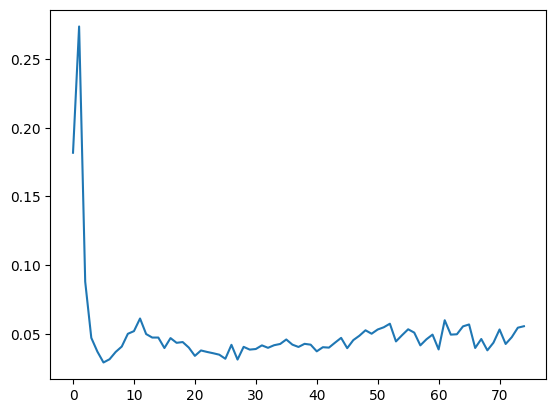

In [165]:
a = [x.item() for x in wica_values]
size = 50
chunks = int(np.ceil(len(a) / size))
chunked = []
a = [np.mean(a[i * size:(i+1)*size]) for i in range(chunks)]
plt.plot(a)

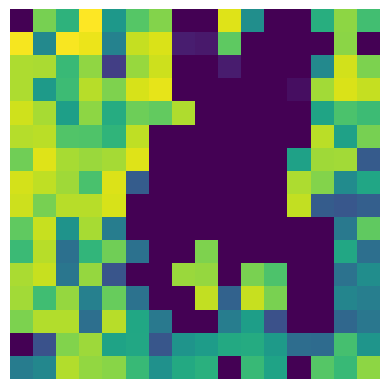

In [160]:
def _get_representative_ids(heatmaps, concept_id):
    """
    Get the top 10 images based on the mean value of the heatmaps for a given concept.

    Parameters
    ----------
    heatmaps : torch.Tensor or np.ndarray
        Batch of heatmaps corresponding to the input images of shape (batch_size, height, width, num_concepts).
    concept_id : int
        Index of the concept to visualize.

    Returns
    -------
    torch.Tensor or np.ndarray
        Indices of the top 10 images based on the mean value of the heatmaps for a given concept.
    """
    if isinstance(heatmaps, torch.Tensor):
        return torch.mean(heatmaps[:, :, :, concept_id], dim=(1, 2)).argsort()[-10:]
    return np.mean(heatmaps[:, :, :, concept_id], axis=(1, 2)).argsort()[-10:]

sae = sae.eval()
with torch.no_grad():
    pre_codes, codes = sae.encode(Activations)

codes = rearrange(codes, '(n w h) d -> n w h d', w=16, h=16)
codes.shape, pre_codes.shape, images.shape

concept_id = 2
best_id = _get_representative_ids(codes, concept_id)[4].item()
im = codes[best_id][:, :, concept_id]

show(images[best_id])
show(im)

Concept 0


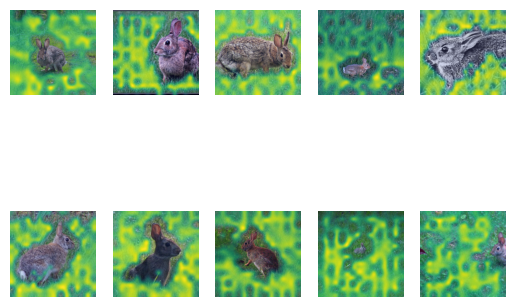

Concept 1


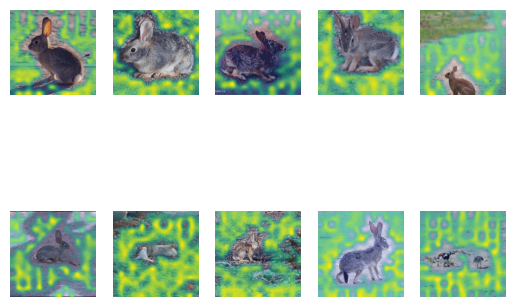

Concept 2


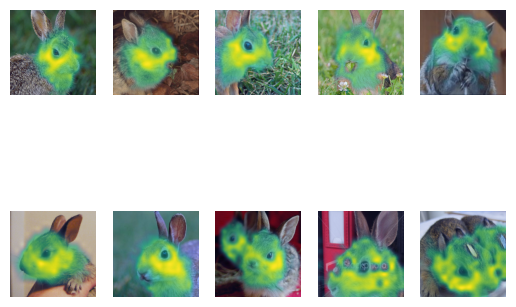

Concept 3


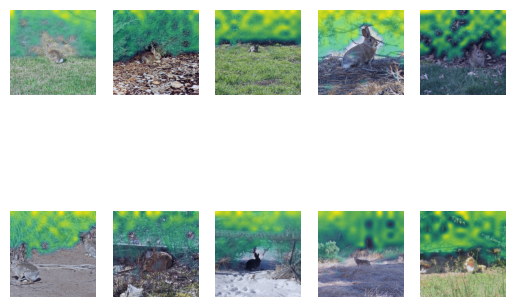

Concept 4


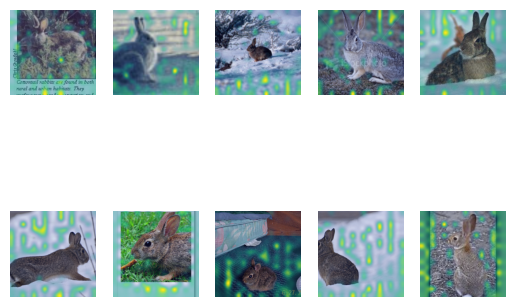

Concept 5


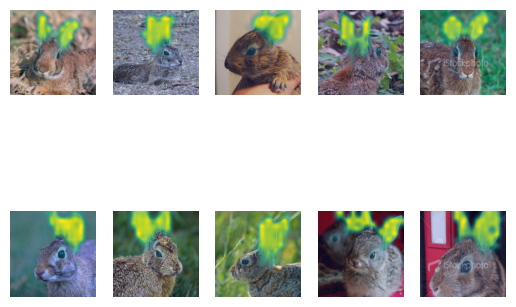

Concept 6


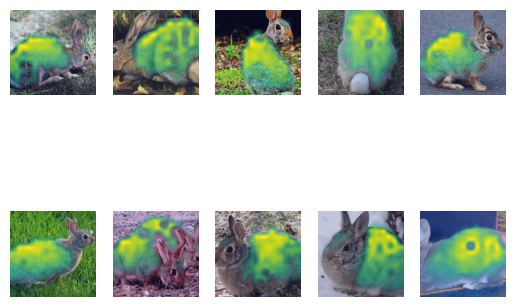

Concept 7


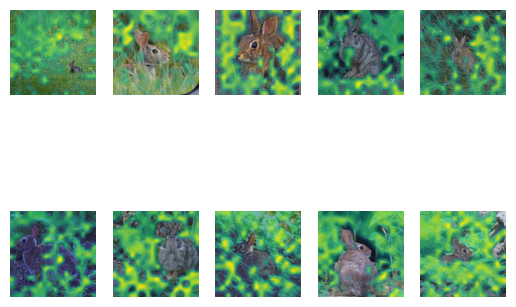

Concept 8


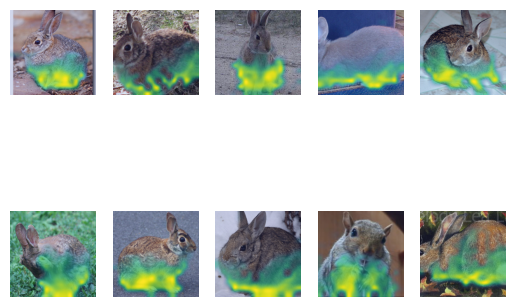

Concept 9


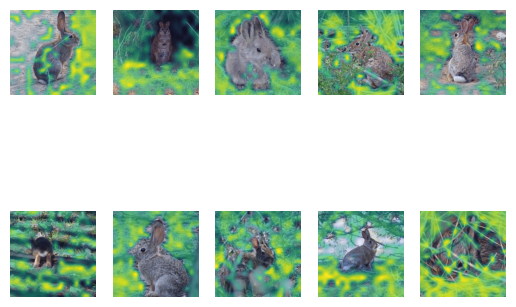

In [166]:
from overcomplete.visualization import overlay_top_heatmaps
# great, now let inspect the results !
# first we reshape the code to see them patch-wise
# then we will use `overlay_top_heatmaps`
# a little function to show the top concepts

sae = sae.eval()

with torch.no_grad():
  pre_codes, codes = sae.encode(Activations)

codes = rearrange(codes, '(n w h) d -> n w h d', w=16, h=16)

for i in range(10):
  print('Concept', i)
  overlay_top_heatmaps(images, codes, concept_id=i)
  plt.show()

# 🎉 Congratulations, you now know how to use Overcomplete